# SSHWS Category IKE Breakdown

Extracts per-storm and per-timestep IKE from IBTrACS across all six basins,
categorized by Saffir-Simpson intensity, and produces the 4-panel figure
comparing wind field size and IKE across categories.


## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

from ike_climatology import config
from ike_climatology.aggregate import extract_category_breakdown_metrics
from ike_climatology.categories import CATEGORY_ORDER
from ike_climatology.style import SSHWS_CATEGORY_COLORS


## Data extraction

`extract_category_breakdown_metrics` handles the full per-basin, per-storm loop
(`prepare_ibtracs_storm` -> `calculate_storm_metrics` -> `passes_quality_filters`)
and returns `peak_df` (one row per storm, categorized by peak and landfall Saffir-Simpson
category) and `inst_df` (one row per qualifying timestep, categorized by instantaneous category).

In [3]:
peak_df, landfall_df, inst_df = extract_category_breakdown_metrics(
    basins=config.BASINS_TO_ANALYZE,
    file_map=config.IBTRACS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)


--- Starting Data Extraction for SSHWS Comparison ---
  - Loading IBTrACS data for North Atlantic (2004-2024)
      > Dropped 2 crossovers based on origin label.
  - Loading IBTrACS data for East Pacific (2004-2024)
      > Dropped 79 crossovers based on origin label.
  - Loading IBTrACS data for West Pacific (2004-2024)
      > Dropped 16 crossovers based on origin label.
  - Loading IBTrACS data for North Indian (2004-2024)
      > Dropped 13 crossovers based on origin label.
  - Loading IBTrACS data for South Indian (2004-2024)
      > Dropped 22 crossovers based on origin label.
  - Loading IBTrACS data for South Pacific (2004-2024)
      > Dropped 12 crossovers based on origin label.
Extraction complete. Generated data for 1708 storms.
  peak_df:      1708 rows
  landfall_df:  1124 rows
  inst_df:      29777 rows


## Figure: 4-panel Saffir-Simpson breakdown

/tmp/ipykernel_2760269/3240064773.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[0, 0], x="peak_cat", y="mean_r34_km", data=p_df,
/tmp/ipykernel_2760269/3240064773.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[0, 1], x="cat", y="ike_tj", data=i_df,
/tmp/ipykernel_2760269/3240064773.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[1, 0], x="peak_cat", y="coincident_ike_tj", data=p_df,
/tmp/ipykernel_2760269/3240064773.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

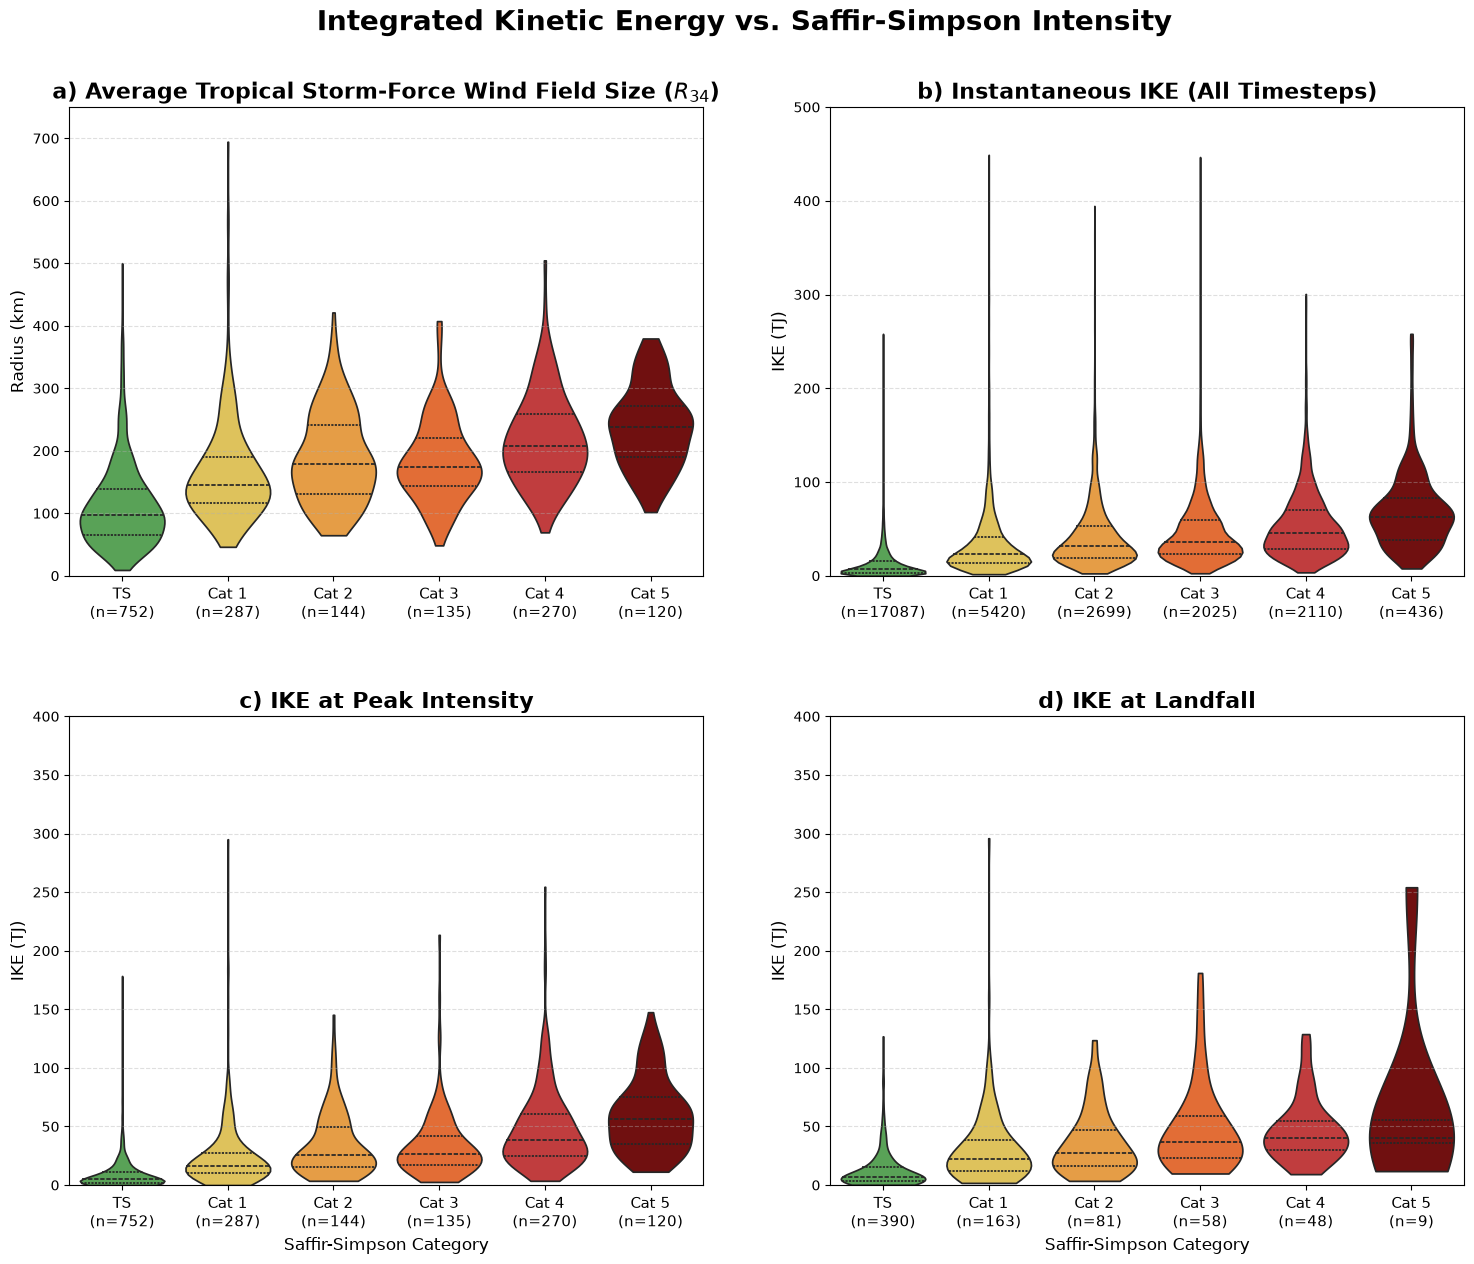

In [4]:
p_df = peak_df[peak_df["peak_cat"] != "TD"].dropna(subset=["coincident_ike_tj"])
i_df = inst_df[inst_df["cat"] != "TD"].dropna(subset=["ike_tj"])
l_df = landfall_df[landfall_df["landfall_cat"] != "TD"].dropna(subset=["landfall_ike_tj"])

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

def add_n_to_labels(ax, df, col_name, order):
    counts = df[col_name].value_counts()
    new_labels = [f"{cat}\n(n={counts.get(cat, 0)})" for cat in order]
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(new_labels, fontsize=11)

# Panel A: Mean R34 size
sns.violinplot(ax=axes[0, 0], x="peak_cat", y="mean_r34_km", data=p_df,
                order=CATEGORY_ORDER, palette=SSHWS_CATEGORY_COLORS, inner="quartile", cut=0)
axes[0, 0].set_title("a) Average Tropical Storm-Force Wind Field Size ($R_{34}$)",
                      fontsize=16, fontweight="bold")
axes[0, 0].set_ylabel("Radius (km)", fontsize=12)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylim(0, 750)
add_n_to_labels(axes[0, 0], p_df, "peak_cat", CATEGORY_ORDER)
# Panel B: Instantaneous IKE
sns.violinplot(ax=axes[0, 1], x="cat", y="ike_tj", data=i_df,
                order=CATEGORY_ORDER, palette=SSHWS_CATEGORY_COLORS, inner="quartile", cut=0)
axes[0, 1].set_title("b) Instantaneous IKE (All Timesteps)", fontsize=16, fontweight="bold")
axes[0, 1].set_ylabel("IKE (TJ)", fontsize=12)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylim(0, 500)
add_n_to_labels(axes[0, 1], i_df, "cat", CATEGORY_ORDER)

# Panel C: IKE at peak intensity
sns.violinplot(ax=axes[1, 0], x="peak_cat", y="coincident_ike_tj", data=p_df,
                order=CATEGORY_ORDER, palette=SSHWS_CATEGORY_COLORS, inner="quartile", cut=0)
axes[1, 0].set_title("c) IKE at Peak Intensity", fontsize=16, fontweight="bold")
axes[1, 0].set_ylabel("IKE (TJ)", fontsize=12)
axes[1, 0].set_xlabel("Saffir-Simpson Category", fontsize=12)
axes[1, 0].set_ylim(0, 400)
add_n_to_labels(axes[1, 0], p_df, "peak_cat", CATEGORY_ORDER)

# Panel D: Landfall IKE
l_df = l_df.dropna(subset=["landfall_ike_tj", "landfall_cat"])
l_df = l_df[l_df["landfall_cat"] != "TD"]
if not l_df.empty:
    sns.violinplot(ax=axes[1, 1], x="landfall_cat", y="landfall_ike_tj", data=l_df,
                    order=CATEGORY_ORDER, palette=SSHWS_CATEGORY_COLORS, inner="quartile", cut=0)
axes[1, 1].set_title("d) IKE at Landfall", fontsize=16, fontweight="bold")
axes[1, 1].set_ylabel("IKE (TJ)", fontsize=12)
axes[1, 1].set_xlabel("Saffir-Simpson Category", fontsize=12)
axes[1, 1].set_ylim(0, 400)
add_n_to_labels(axes[1, 1], l_df, "landfall_cat", CATEGORY_ORDER)

for ax in axes.flatten():
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.suptitle("Integrated Kinetic Energy vs. Saffir-Simpson Intensity",
             fontsize=20, fontweight="bold", y=0.95)
plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, "ss_breakdown_4panel.png"),
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
